In [1]:
!pip install -q "gymnasium[atari]" ale-py

import os
os.environ.setdefault("CUBLAS_WORKSPACE_CONFIG", ":4096:8")

import random
import collections
import gc
import time
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
import ale_py
from gymnasium.wrappers import AtariPreprocessing, FrameStackObservation

import torch
import torch.nn as nn
import torch.optim as optim

SEEDS = [1, 2, 3]
EVAL_BASE_SEED = 1000
N_EVAL_EPISODES = 20

BUFFER_CAPACITY = 100_000
TOTAL_STEPS = 1_800_000
LEARNING_STARTS = 20_000
TRAIN_FREQ = 4
EPS_START = 1.0
EPS_END = 0.01
DECAY_STEPS = 800_000
GAMMA = 0.99
BATCH_SIZE = 64
LR = 1e-4
TARGET_UPDATE = 2_000
CHECKPOINTS = [600_000, 1_200_000, 1_800_000]
HUMAN_BENCHMARK = 9.3

OUTPUT_DIR = Path("ddqn_multiseed")
CHECKPOINT_DIR = OUTPUT_DIR / "checkpoints"
FIGURE_DIR = OUTPUT_DIR / "figures"
OUTPUT_DIR.mkdir(exist_ok=True)
CHECKPOINT_DIR.mkdir(exist_ok=True)
FIGURE_DIR.mkdir(exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Dispositivo:", device)
print("Training seeds:", SEEDS)

torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True
if hasattr(torch.backends, "cuda") and hasattr(torch.backends.cuda, "matmul"):
    torch.backends.cuda.matmul.allow_tf32 = False
if hasattr(torch.backends, "cudnn"):
    torch.backends.cudnn.allow_tf32 = False
torch.use_deterministic_algorithms(True)


Dispositivo: cuda
Training seeds: [1, 2, 3]


In [2]:
def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)


class FireResetEnv(gym.Wrapper):
    def reset(self, **kwargs):
        obs, info = self.env.reset(**kwargs)
        obs, _, term, trunc, info = self.env.step(1)
        if term or trunc:
            obs, info = self.env.reset(**kwargs)
        return obs, info


class PongThreeActions(gym.ActionWrapper):
    def __init__(self, env, action_seed=None):
        super().__init__(env)
        self.action_mapping = [0, 2, 3]
        self.action_space = gym.spaces.Discrete(3)
        if action_seed is not None:
            self.action_space.seed(action_seed)

    def action(self, act):
        return self.action_mapping[int(act)]


def make_env(action_seed=None):
    env = gym.make("ALE/Pong-v5", frameskip=1)
    env = AtariPreprocessing(
        env,
        noop_max=30,
        frame_skip=4,
        screen_size=84,
        terminal_on_life_loss=False,
        grayscale_obs=True,
        scale_obs=False,
    )
    env = FireResetEnv(env)
    env = PongThreeActions(env, action_seed=action_seed)
    env = FrameStackObservation(env, stack_size=4)
    return env


class DQN(nn.Module):
    def __init__(self, n_actions):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(4, 32, 8, stride=4),
            nn.ReLU(),
            nn.Conv2d(32, 64, 4, stride=2),
            nn.ReLU(),
            nn.Conv2d(64, 64, 3, stride=1),
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 512),
            nn.ReLU(),
            nn.Linear(512, n_actions),
        )

    def forward(self, x):
        return self.net(x / 255.0)


class ReplayBuffer:
    def __init__(self, capacity=100_000):
        self.buffer = collections.deque(maxlen=capacity)

    def push(self, s, a, r, next_s, done):
        self.buffer.append((
            np.array(s, dtype=np.uint8),
            int(a),
            float(r),
            np.array(next_s, dtype=np.uint8),
            bool(done),
        ))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        s, a, r, next_s, d = zip(*batch)
        return (
            torch.tensor(np.array(s), dtype=torch.uint8, device=device).float(),
            torch.tensor(a, dtype=torch.int64, device=device),
            torch.tensor(r, dtype=torch.float32, device=device),
            torch.tensor(np.array(next_s), dtype=torch.uint8, device=device).float(),
            torch.tensor(d, dtype=torch.float32, device=device),
        )

    def __len__(self):
        return len(self.buffer)


def evaluate(eval_env, model=None, episodes=N_EVAL_EPISODES, base_seed=EVAL_BASE_SEED):
    scores = []
    for i in range(episodes):
        episode_seed = base_seed + i
        state, _ = eval_env.reset(seed=episode_seed)

        if model is None:
            eval_env.action_space.seed(episode_seed)

        done = False
        total_reward = 0.0

        while not done:
            if model is None:
                action = eval_env.action_space.sample()
            else:
                state_t = torch.as_tensor(
                    np.asarray(state), dtype=torch.uint8, device=device
                ).float().unsqueeze(0)
                with torch.inference_mode():
                    action = int(model(state_t).argmax(dim=1).item())

            state, reward, term, trunc, _ = eval_env.step(action)
            done = term or trunc
            total_reward += float(reward)

        scores.append(total_reward)

    scores = np.asarray(scores, dtype=np.float32)
    return float(scores.mean()), float(scores.std(ddof=0)), scores


In [3]:
_rand_env = make_env(action_seed=EVAL_BASE_SEED)
rand_mean, rand_std, rand_scores = evaluate(_rand_env, model=None)
_rand_env.close()
print(f"Random Baseline: {rand_mean:.2f} +/- {rand_std:.2f}")


def train_one_seed(seed):
    seed_everything(seed)

    env = make_env(action_seed=seed)
    eval_env = make_env(action_seed=EVAL_BASE_SEED)
    n_actions = env.action_space.n

    policy_net = DQN(n_actions).to(device)
    target_net = DQN(n_actions).to(device)
    target_net.load_state_dict(policy_net.state_dict())
    target_net.eval()

    optimizer = optim.Adam(policy_net.parameters(), lr=LR)
    loss_fn = nn.SmoothL1Loss()
    buffer = ReplayBuffer(capacity=BUFFER_CAPACITY)

    state, _ = env.reset(seed=seed)
    ep_reward = 0.0
    rewards_history = []
    step_history = []
    loss_history = []
    target_gap_history = []
    checkpoint_results = {}

    policy_net.train()
    start_time = time.time()

    for step in range(1, TOTAL_STEPS + 1):
        eps = max(
            EPS_END,
            EPS_START - (EPS_START - EPS_END) * (step / DECAY_STEPS),
        )

        if random.random() < eps:
            action = env.action_space.sample()
        else:
            state_t = torch.as_tensor(
                np.asarray(state), dtype=torch.uint8, device=device
            ).float().unsqueeze(0)
            with torch.inference_mode():
                action = int(policy_net(state_t).argmax(dim=1).item())

        next_state, reward, term, trunc, _ = env.step(action)
        buffer.push(state, action, reward, next_state, term)

        state = next_state
        ep_reward += float(reward)

        if term or trunc:
            rewards_history.append(ep_reward)
            step_history.append(step)

            if len(rewards_history) % 20 == 0:
                avg_recent = np.mean(rewards_history[-20:])
                elapsed = (time.time() - start_time) / 60.0
                print(
                    f"[seed {seed}] Step {step:7d}/{TOTAL_STEPS} | "
                    f"Episodio {len(rewards_history):4d} | "
                    f"Media ultimi 20: {avg_recent:6.2f} | "
                    f"eps: {eps:.3f} | {elapsed:.1f} min",
                    flush=True,
                )

            state, _ = env.reset()
            ep_reward = 0.0

        if step > LEARNING_STARTS and step % TRAIN_FREQ == 0:
            b_s, b_a, b_r, b_ns, b_d = buffer.sample(BATCH_SIZE)

            with torch.no_grad():

                best_actions = policy_net(b_ns).argmax(dim=1, keepdim=True)
                ddqn_next_q = target_net(b_ns).gather(
                    1, best_actions
                ).squeeze(1)

                target_q = b_r + (1.0 - b_d) * GAMMA * ddqn_next_q


                dqn_next_q = target_net(b_ns).max(dim=1).values
                target_gap = (
                    GAMMA
                    * (1.0 - b_d)
                    * (dqn_next_q - ddqn_next_q)
                ).mean().item()
                target_gap_history.append(float(target_gap))

            current_q = policy_net(b_s).gather(
                1, b_a.unsqueeze(1)
            ).squeeze(1)

            loss = loss_fn(current_q, target_q)

            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            nn.utils.clip_grad_norm_(policy_net.parameters(), 1.0)
            optimizer.step()

            loss_history.append(float(loss.item()))

        if step % TARGET_UPDATE == 0:
            target_net.load_state_dict(policy_net.state_dict())

        if step % 100_000 == 0:
            gc.collect()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

        if step in CHECKPOINTS:
            policy_net.eval()
            m_score, s_score, scores = evaluate(eval_env, model=policy_net)
            policy_net.train()

            checkpoint_results[step] = {
                "mean": m_score,
                "episode_std": s_score,
                "scores": scores.tolist(),
            }

            path = CHECKPOINT_DIR / f"double_dqn_pong_seed{seed}_{step}.pth"
            torch.save(policy_net.state_dict(), path)

            print(
                f"\n--- seed {seed} | checkpoint {step}: "
                f"{m_score:.2f} +/- {s_score:.2f} ---\n",
                flush=True,
            )

    env.close()
    eval_env.close()

    np.savez_compressed(
        OUTPUT_DIR / f"ddqn_seed{seed}_history.npz",
        step_history=np.asarray(step_history, dtype=np.int64),
        rewards_history=np.asarray(rewards_history, dtype=np.float32),
        loss_history=np.asarray(loss_history, dtype=np.float32),
        target_gap_history=np.asarray(target_gap_history, dtype=np.float32),
    )

    result = {
        "seed": seed,
        "checkpoints": checkpoint_results,
        "final_checkpoint": str(
            CHECKPOINT_DIR / f"double_dqn_pong_seed{seed}_{TOTAL_STEPS}.pth"
        ),
        "n_episodes": len(rewards_history),
        "n_updates": len(loss_history),
    }

    del buffer, optimizer, target_net, policy_net
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return result


runs = {}
for seed in SEEDS:
    print("\n" + "=" * 80)
    print(f"TRAINING DOUBLE DQN — seed {seed}")
    print("=" * 80)
    runs[seed] = train_one_seed(seed)

print("\nTre training Double DQN completati.")


A.L.E: Arcade Learning Environment (version 0.11.2+ecc1138)
[Powered by Stella]


Random Baseline: -20.40 +/- 0.86

TRAINING DOUBLE DQN — seed 1
[seed 1] Step   18974/1800000 | Episodio   20 | Media ultimi 20: -20.60 | eps: 0.977 | 0.4 min
[seed 1] Step   38485/1800000 | Episodio   40 | Media ultimi 20: -20.65 | eps: 0.952 | 1.4 min
[seed 1] Step   58494/1800000 | Episodio   60 | Media ultimi 20: -20.50 | eps: 0.928 | 2.5 min
[seed 1] Step   77823/1800000 | Episodio   80 | Media ultimi 20: -20.60 | eps: 0.904 | 3.6 min
[seed 1] Step   98152/1800000 | Episodio  100 | Media ultimi 20: -20.75 | eps: 0.879 | 4.7 min
[seed 1] Step  119971/1800000 | Episodio  120 | Media ultimi 20: -20.25 | eps: 0.852 | 5.9 min
[seed 1] Step  142233/1800000 | Episodio  140 | Media ultimi 20: -20.15 | eps: 0.824 | 7.2 min
[seed 1] Step  167443/1800000 | Episodio  160 | Media ultimi 20: -19.75 | eps: 0.793 | 8.6 min
[seed 1] Step  192984/1800000 | Episodio  180 | Media ultimi 20: -19.60 | eps: 0.761 | 10.1 min
[seed 1] Step  219243/1800000 | Episodio  200 | Media ultimi 20: -19.65 | eps: 0.


--- RISULTATI AGGREGATI DOUBLE DQN ---
Random Agent: -20.40 +/- 0.86 (variabilità tra episodi)
Human reference: 9.30
 600k | mean across seeds = -9.68 +/- 1.29 | 1: -8.75, 2: -9.15, 3: -11.15
1200k | mean across seeds = 7.22 +/- 9.10 | 1: 13.90, 2: 10.90, 3: -3.15
1800k | mean across seeds = 15.68 +/- 1.67 | 1: 17.00, 2: 16.25, 3: 13.80


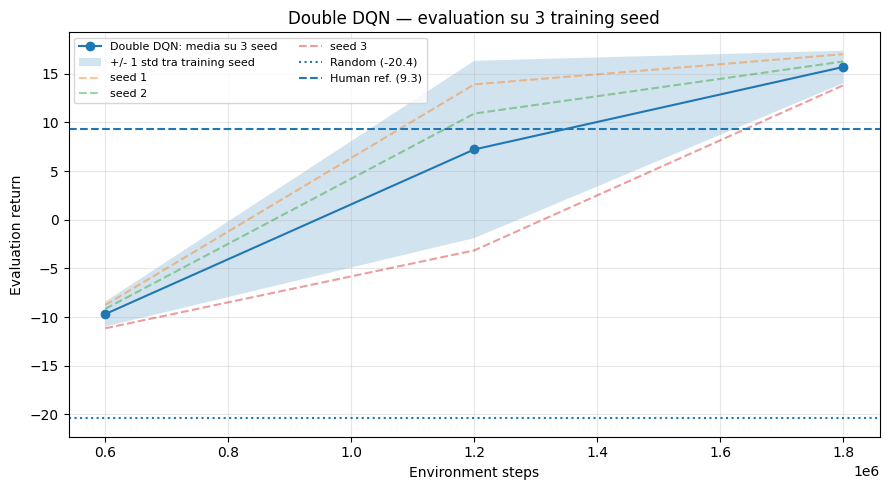

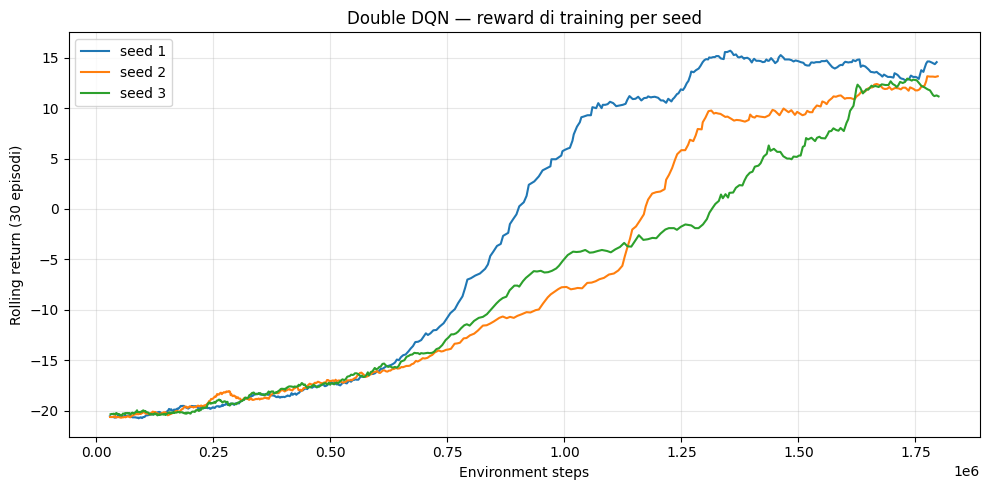

In [4]:



checkpoint_matrix = np.asarray([
    [runs[s]["checkpoints"][step]["mean"] for step in CHECKPOINTS]
    for s in SEEDS
], dtype=np.float64)

mean_across_seeds = checkpoint_matrix.mean(axis=0)
std_across_seeds = checkpoint_matrix.std(axis=0, ddof=1)

print("\n--- RISULTATI AGGREGATI DOUBLE DQN ---")
print(f"Random Agent: {rand_mean:.2f} +/- {rand_std:.2f} (variabilità tra episodi)")
print(f"Human reference: {HUMAN_BENCHMARK:.2f}")
for j, step in enumerate(CHECKPOINTS):
    individual = ", ".join(
        f"{seed}: {checkpoint_matrix[i, j]:.2f}"
        for i, seed in enumerate(SEEDS)
    )
    print(
        f"{step//1000:4d}k | mean across seeds = "
        f"{mean_across_seeds[j]:.2f} +/- {std_across_seeds[j]:.2f} | {individual}"
    )

summary = {
    "algorithm": "Double DQN",
    "training_seeds": SEEDS,
    "evaluation_base_seed": EVAL_BASE_SEED,
    "evaluation_episodes": N_EVAL_EPISODES,
    "random_baseline": {
        "mean": rand_mean,
        "episode_std": rand_std,
        "scores": rand_scores.tolist(),
    },
    "checkpoints": {},
}
for j, step in enumerate(CHECKPOINTS):
    summary["checkpoints"][str(step)] = {
        "mean_across_training_seeds": float(mean_across_seeds[j]),
        "std_across_training_seeds": float(std_across_seeds[j]),
        "per_seed": {
            str(seed): runs[seed]["checkpoints"][step]
            for seed in SEEDS
        },
    }

with open(OUTPUT_DIR / "ddqn_multiseed_summary.json", "w") as f:
    json.dump(summary, f, indent=2)


fig, ax = plt.subplots(figsize=(9, 5))
x = np.asarray(CHECKPOINTS)
ax.plot(x, mean_across_seeds, marker="o", label="Double DQN: media su 3 seed")
ax.fill_between(
    x,
    mean_across_seeds - std_across_seeds,
    mean_across_seeds + std_across_seeds,
    alpha=0.2,
    label="+/- 1 std tra training seed",
)
for i, seed in enumerate(SEEDS):
    ax.plot(x, checkpoint_matrix[i], linestyle="--", alpha=0.45, label=f"seed {seed}")
ax.axhline(rand_mean, linestyle=":", label=f"Random ({rand_mean:.1f})")
ax.axhline(HUMAN_BENCHMARK, linestyle="--", label=f"Human ref. ({HUMAN_BENCHMARK})")
ax.set_xlabel("Environment steps")
ax.set_ylabel("Evaluation return")
ax.set_title("Double DQN — evaluation su 3 training seed")
ax.grid(True, alpha=0.3)
ax.legend(ncol=2, fontsize=8)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "ddqn_multiseed_evaluation.png", dpi=160)
plt.show()
plt.close(fig)


fig, ax = plt.subplots(figsize=(10, 5))
for seed in SEEDS:
    h = np.load(OUTPUT_DIR / f"ddqn_seed{seed}_history.npz")
    rewards = h["rewards_history"]
    steps = h["step_history"]
    if len(rewards) >= 30:
        rolling = np.convolve(rewards, np.ones(30) / 30.0, mode="valid")
        ax.plot(steps[29:], rolling, label=f"seed {seed}")
ax.set_xlabel("Environment steps")
ax.set_ylabel("Rolling return (30 episodi)")
ax.set_title("Double DQN — reward di training per seed")
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()
fig.savefig(FIGURE_DIR / "ddqn_training_rewards_3seeds.png", dpi=160)
plt.show()
plt.close(fig)


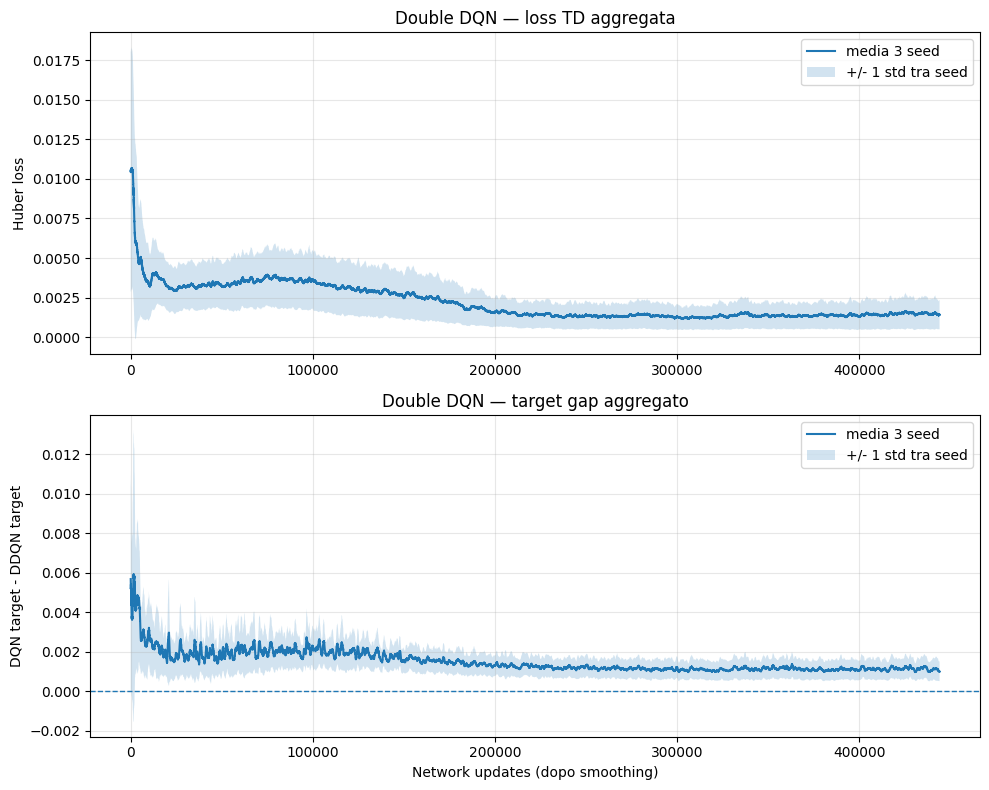

Output salvati in: /kaggle/working/ddqn_multiseed


In [5]:



histories = {
    seed: np.load(OUTPUT_DIR / f"ddqn_seed{seed}_history.npz")
    for seed in SEEDS
}

loss_arrays = [histories[s]["loss_history"] for s in SEEDS]
gap_arrays = [histories[s]["target_gap_history"] for s in SEEDS]

min_loss_len = min(map(len, loss_arrays))
min_gap_len = min(map(len, gap_arrays))

loss_stack = np.stack([x[:min_loss_len] for x in loss_arrays])
gap_stack = np.stack([x[:min_gap_len] for x in gap_arrays])

SMOOTH = 1000

def moving_average(x, window):
    if len(x) < window:
        return x
    kernel = np.ones(window, dtype=np.float64) / window
    return np.convolve(x, kernel, mode="valid")


loss_mean = loss_stack.mean(axis=0)
loss_std = loss_stack.std(axis=0, ddof=1)
gap_mean = gap_stack.mean(axis=0)
gap_std = gap_stack.std(axis=0, ddof=1)

loss_mean_s = moving_average(loss_mean, SMOOTH)
loss_lo_s = moving_average(loss_mean - loss_std, SMOOTH)
loss_hi_s = moving_average(loss_mean + loss_std, SMOOTH)

gap_mean_s = moving_average(gap_mean, SMOOTH)
gap_lo_s = moving_average(gap_mean - gap_std, SMOOTH)
gap_hi_s = moving_average(gap_mean + gap_std, SMOOTH)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

x_loss = np.arange(len(loss_mean_s))
ax1.plot(x_loss, loss_mean_s, label="media 3 seed")
ax1.fill_between(x_loss, loss_lo_s, loss_hi_s, alpha=0.2, label="+/- 1 std tra seed")
ax1.set_ylabel("Huber loss")
ax1.set_title("Double DQN — loss TD aggregata")
ax1.grid(True, alpha=0.3)
ax1.legend()

x_gap = np.arange(len(gap_mean_s))
ax2.plot(x_gap, gap_mean_s, label="media 3 seed")
ax2.fill_between(x_gap, gap_lo_s, gap_hi_s, alpha=0.2, label="+/- 1 std tra seed")
ax2.axhline(0.0, linestyle="--", linewidth=1)
ax2.set_xlabel("Network updates (dopo smoothing)")
ax2.set_ylabel("DQN target - DDQN target")
ax2.set_title("Double DQN — target gap aggregato")
ax2.grid(True, alpha=0.3)
ax2.legend()

fig.tight_layout()
fig.savefig(FIGURE_DIR / "ddqn_loss_and_target_gap_3seeds.png", dpi=160)
plt.show()
plt.close(fig)

print(f"Output salvati in: {OUTPUT_DIR.resolve()}")
